# Assess the Exploration 


In this notebook we inspect the training state via: 
1. Reward as function of episodes with smoothing-window function. 
2. Reward as function of time evolution within an episode 
3. Actor and critic loss during exploration. 

In [50]:
%matplotlib inline
import numpy as np  
import os 
import matplotlib.pyplot as plt 
import pandas as pd 
from postlib.plot import plt_setUp, colorplate as cc
from postlib.explore import * 
import datetime
# Environment 
color_list = [cc.deepgreen,cc.deepblue,cc.deeppurple,cc.orange,cc.yellow,cc.red,cc.blue,cc.yellow2,cc.lightblue,cc.pink,cc.darkred, cc.black]
plt_setUp()
run_path = "/p/project1/deepwing/polsm/11-MARL-ZeroShot-Nek5000/runs"
fig_path = "Figs"
SAVE_IMG = False
if not os.path.exists(fig_path):
    
    os.makedirs(fig_path)


## Add your case

In [51]:
# Case list 
# Case list 
case_tuple = [
            (2003, "ng-100: α=1 β=0 γ=0"),   # drag reduction only
            (2004, "ng-110: α=1 β=1 γ=0"),   # drag + pressure-vel cost
            (2005, "ng-111: α=1 β=1 γ=1"),   # full net-gain
            (2006, "ng-011: α=0 β=1 γ=1"),   # actuator costs only
            (2007, "ng-101: α=1 β=0 γ=1"),   # drag + kinetic energy cost
            ]
case_list = [case_tuple[i][0] for i in range(len(case_tuple))]
case_name = [case_tuple[i][1] for i in range(len(case_tuple))]
case_dict = initalize_case(run_path,case_list)
            

---- Start Case 1 ----
Reward list: 23 files
Reward smooth: (50801,)
Reward mean max R: 47.78 at episode 17


Components loaded: 54091 steps, 21 episodes
---- End ----

---- Start Case 2 ----
Reward list: 23 files
Reward smooth: (50801,)
Reward mean max R: -28.10 at episode 1
Components loaded: 54091 steps, 21 episodes
---- End ----

---- Start Case 3 ----
Reward list: 23 files
Reward smooth: (50801,)
Reward mean max R: -4.72 at episode 19
Components loaded: 54401 steps, 21 episodes
---- End ----

---- Start Case 4 ----
Reward list: 23 files
Reward smooth: (50801,)
Reward mean max R: -17.35 at episode 16
Components loaded: 54121 steps, 21 episodes
---- End ----

---- Start Case 5 ----
Reward list: 23 files
Reward smooth: (50801,)
Reward mean max R: 49.19 at episode 2
Components loaded: 54121 steps, 21 episodes
---- End ----



## Reward evolution as function of epsiode with smooth func
+ Using a convolution to smooth the reward evolution step by step. 
+ Depict the continuous evolution of reward throughout the exploration.  

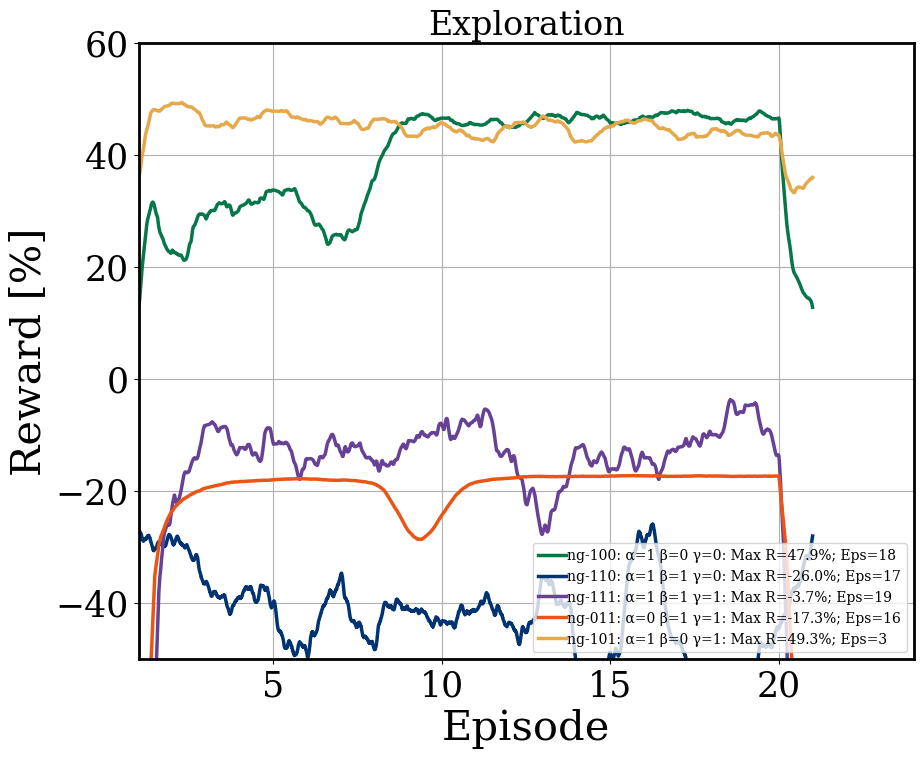

In [52]:

fig,axs = plt.subplots(1,1,figsize=(10,8))

eps_max = -1 
for il, case in enumerate(case_list):
    label = case_name[il] 
    label = label + ": Max R={:.1f}%".format(case_dict[case]['reward_smooth_max'])
    label = label + "; Eps={}".format(case_dict[case]['reward_smooth_max_index'])
    axs.plot(case_dict[case]['episode'], case_dict[case]['reward_smooth'],lw=2.5,c=color_list[il],label=label)

    # better visualization
    len_eps = np.max(case_dict[case]['episode'])
    if eps_max < len_eps: 
        eps_max = len_eps 
        
axs.set_xlabel("Episode",)
axs.set_ylabel("Reward [%]",)
axs.set_ylim(-50,60); axs.set_xlim(1,np.ceil(1.1*eps_max))
axs.set_title("Exploration",)
axs.grid(True)
axs.legend(loc='lower right',prop={'size': 10})
plt.show()
if SAVE_IMG: 
    plt.savefig(f"{fig_path}/reward_smooth_episode_{datetime.datetime.now().strftime('%Y%m%d_%H%M%S')}.png",dpi=299)

## Mean Reward Evolution
+ No sliding-window smoother.
+ Depict the evolution of mean reward of each epiosde
+ Useful to select the best model

Case-2003: current R=12.76%
Case-2004: current R=-28.10%
Case-2005: current R=-144.13%
Case-2006: current R=-78.03%
Case-2007: current R=35.92%


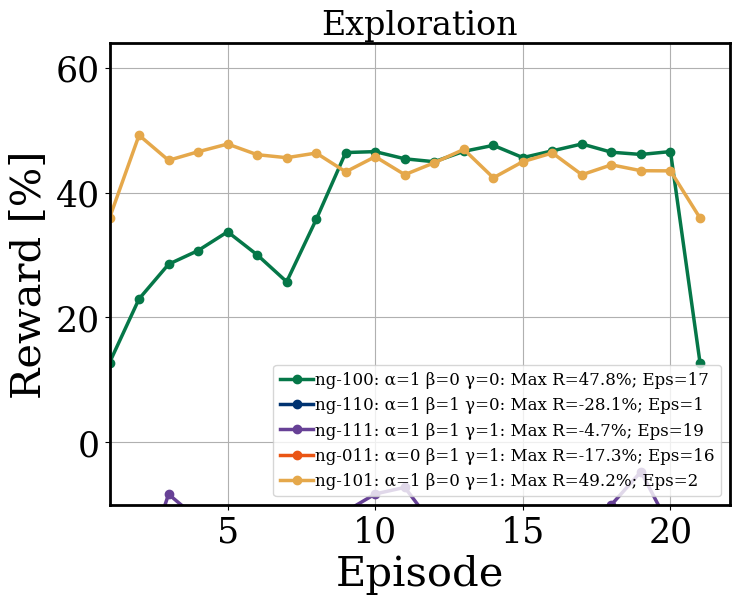

In [53]:

fig,axs = plt.subplots(1,1,figsize=(8,6))

eps_max = -1
rew_max = -1.0 
for il, case in enumerate(case_list):
    label = case_name[il] 
    label = label + ": Max R={:.1f}%".format(case_dict[case]['reward_mean_max'])
    label = label + "; Eps={}".format(case_dict[case]['reward_max_index'])
    axs.plot(case_dict[case]['episode_idx'], case_dict[case]['reward_mean'],
             marker='o',
             lw=2.5,c=color_list[il],label=label)

    print(f"Case-{case}: current R={case_dict[case]['reward_mean'][-1]:.2f}%") 
    
    # better visualization
    len_eps = np.max(case_dict[case]['episode_idx'])
    if eps_max < len_eps: 
        eps_max = len_eps 
    if rew_max < case_dict[case]['reward_mean_max']:
        rew_max  = case_dict[case]['reward_mean_max']

axs.set_xlabel("Episode",); axs.set_ylabel("Reward [%]",)
axs.set_ylim(-10,np.ceil(rew_max*1.3));axs.set_xlim(1,np.ceil(1.01*eps_max))
axs.set_title("Exploration",)
axs.grid(True)
axs.legend(loc='lower right',prop={'size': 12})
plt.show()
if SAVE_IMG: 
    plt.savefig(f"{fig_path}/reward_smooth_episode_{datetime.datetime.now().strftime('%Y%m%d_%H%M%S')}.png",dpi=299)

## Reward Components — Smoothed Evolution
+ Same sliding-window smoother as the total reward plot.
+ Three panels: R_τ (drag reduction), R_pw (pressure·velocity cost), R_v3 (kinetic energy cost).
+ Allows diagnosing which term drives the total reward for each ablation case.

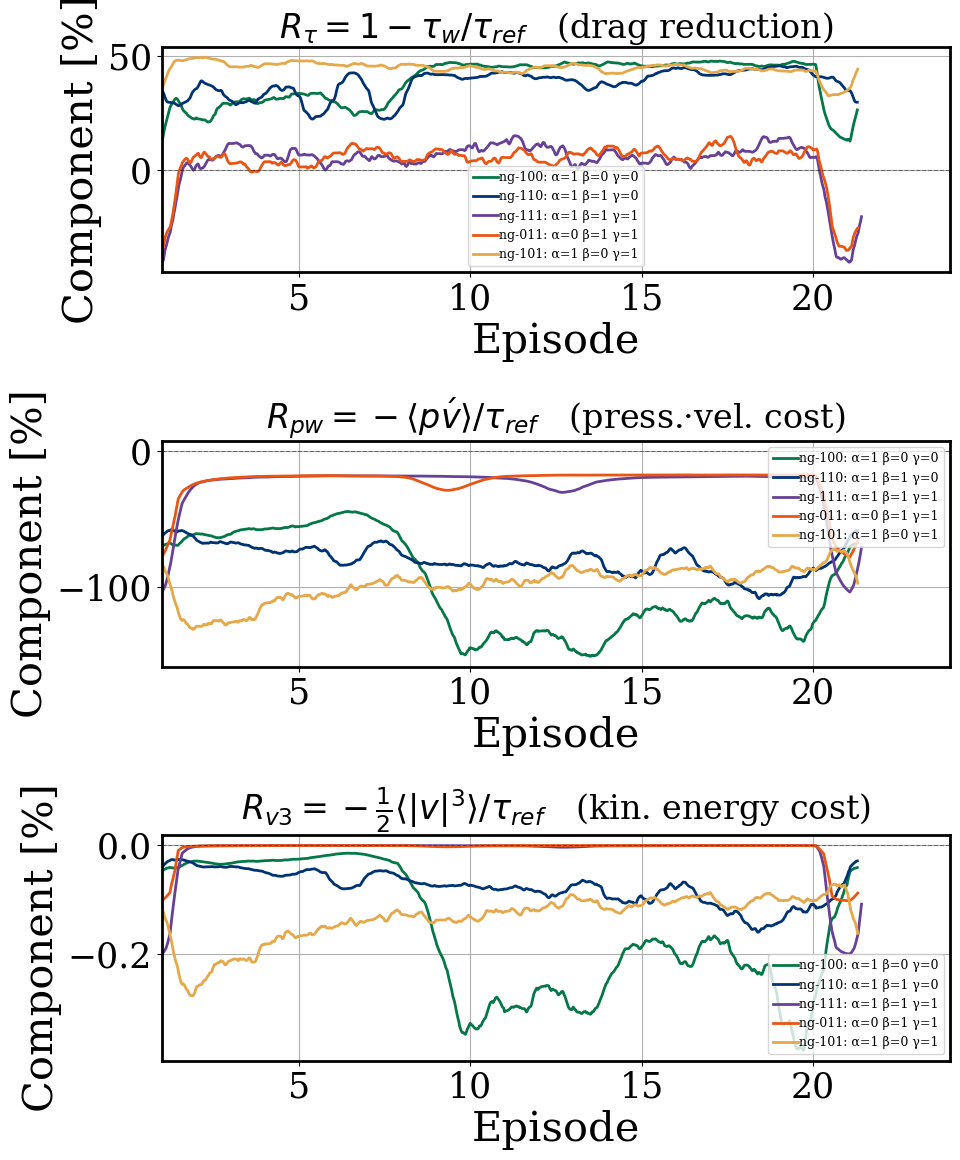

In [54]:
comp_labels = [
    ('mean_R_tau_smooth', 'comp_episode',
     r'$R_\tau = 1 - \tau_w/\tau_{ref}$   (drag reduction)'),
    ('mean_R_pw_smooth',  'comp_episode',
     r'$R_{pw} = -\langle p\'v \rangle / \tau_{ref}$   (press.·vel. cost)'),
    ('mean_R_v3_smooth',  'comp_episode',
     r'$R_{v3} = -\frac{1}{2}\langle|v|^3\rangle / \tau_{ref}$   (kin. energy cost)'),
]

fig, axs = plt.subplots(3, 1, figsize=(10, 12))
eps_max = -1

for il, case in enumerate(case_list):
    if 'mean_R_tau_smooth' not in case_dict[case]:
        print(f"Case {case}: no component data"); continue
    for ax, (skey, xkey, _) in zip(axs, comp_labels):
        x = case_dict[case][xkey]
        y = case_dict[case][skey]
        ax.plot(x, y, lw=2.0, c=color_list[il], label=case_name[il])
    eps_max = max(eps_max, float(np.max(case_dict[case]['comp_episode'])))

for ax, (_, _, title) in zip(axs, comp_labels):
    ax.axhline(0, color='k', lw=0.8, ls='--', alpha=0.4)
    ax.set_xlabel("Episode")
    ax.set_ylabel("Component [%]")
    ax.set_title(title)
    ax.grid(True)
    ax.legend(loc='best', prop={'size': 9})
    if eps_max > 0:
        ax.set_xlim(1, np.ceil(1.1 * eps_max))

plt.tight_layout()
plt.show()
if SAVE_IMG:
    plt.savefig(f"{fig_path}/components_smooth_{datetime.datetime.now().strftime('%Y%m%d_%H%M%S')}.png", dpi=299)

## Reward Components — Episode-level Mean
+ No smoother: one point per complete episode.
+ Useful for selecting the best model per component (e.g. best drag reducer vs. best net-gain).

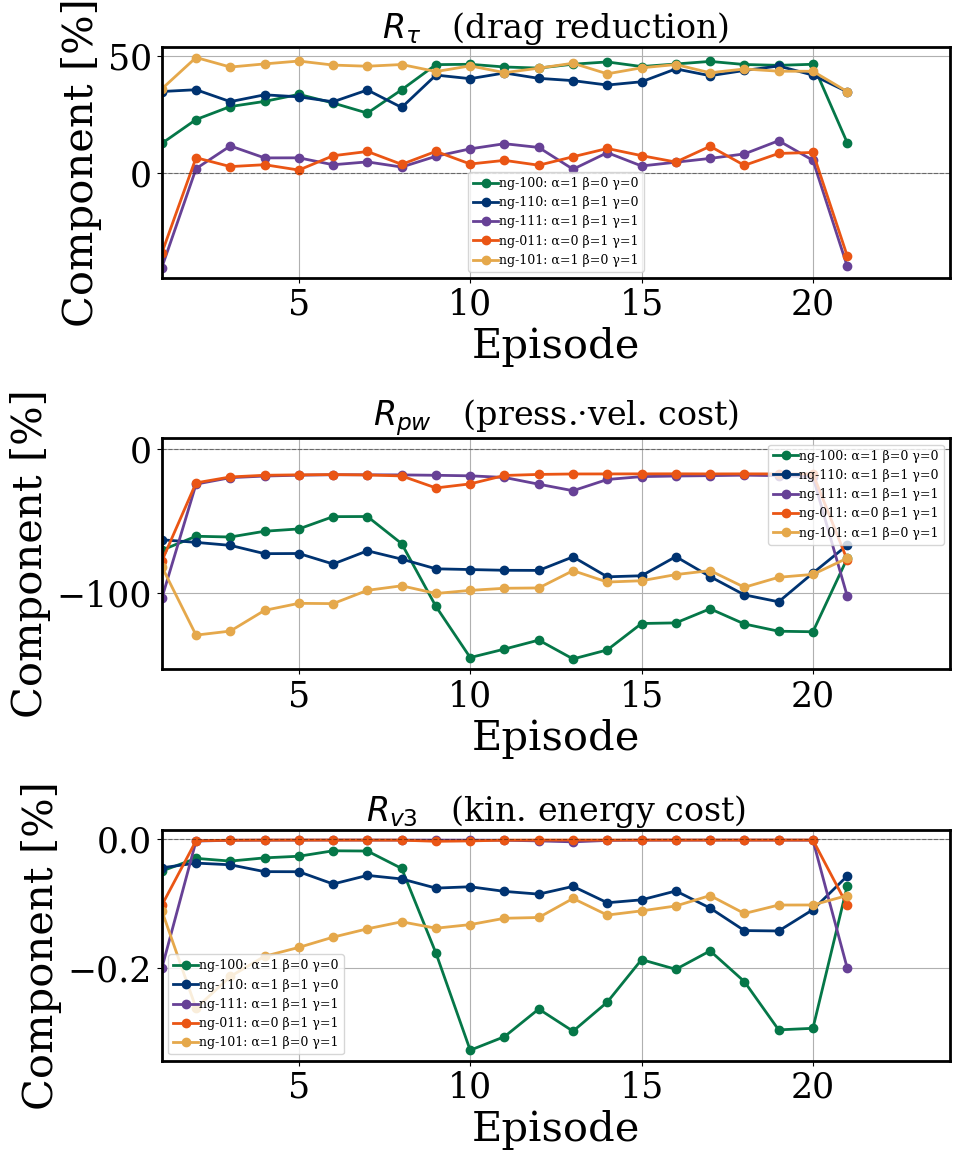

In [55]:
ep_comp_keys = [
    ('mean_R_tau_eps', r'$R_\tau$   (drag reduction)'),
    ('mean_R_pw_eps',  r'$R_{pw}$   (press.·vel. cost)'),
    ('mean_R_v3_eps',  r'$R_{v3}$   (kin. energy cost)'),
]

fig, axs = plt.subplots(3, 1, figsize=(10, 12))
eps_max = -1

for il, case in enumerate(case_list):
    if 'mean_R_tau_eps' not in case_dict[case]:
        print(f"Case {case}: no component data"); continue
    ep_idx = case_dict[case]['comp_episode_idx']
    for ax, (key, _) in zip(axs, ep_comp_keys):
        ax.plot(ep_idx, case_dict[case][key],
                marker='o', lw=2.0, c=color_list[il], label=case_name[il])
    eps_max = max(eps_max, float(np.max(ep_idx)))

for ax, (_, title) in zip(axs, ep_comp_keys):
    ax.axhline(0, color='k', lw=0.8, ls='--', alpha=0.4)
    ax.set_xlabel("Episode")
    ax.set_ylabel("Component [%]")
    ax.set_title(title)
    ax.grid(True)
    ax.legend(loc='best', prop={'size': 9})
    if eps_max > 0:
        ax.set_xlim(1, np.ceil(1.1 * eps_max))

plt.tight_layout()
plt.show()
if SAVE_IMG:
    plt.savefig(f"{fig_path}/components_episodes_{datetime.datetime.now().strftime('%Y%m%d_%H%M%S')}.png", dpi=299)

## Actor and Critic Loss on training

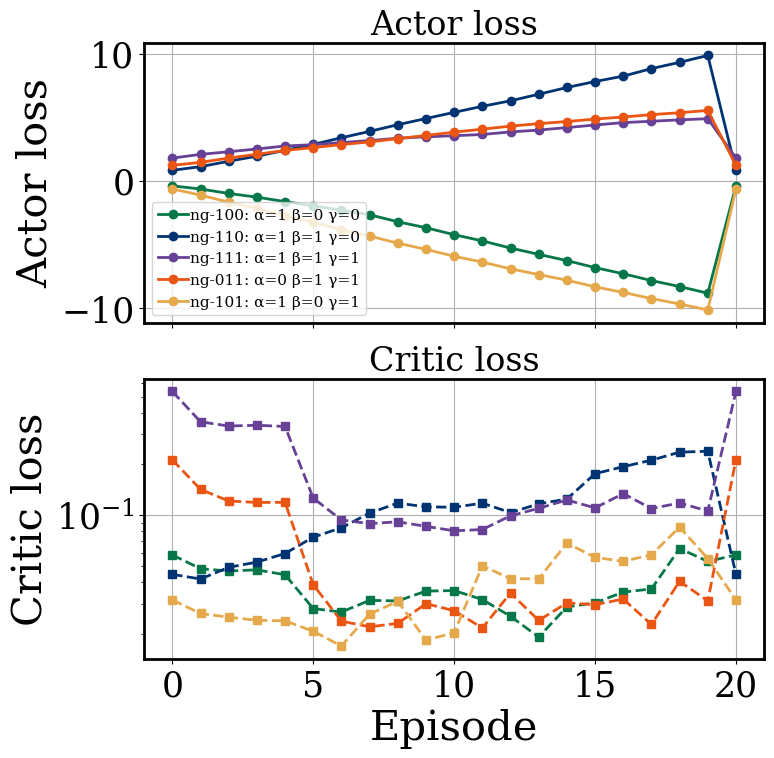

In [56]:
fig,axs = plt.subplots(2,1,figsize=(8,8),sharex=True)
for il, case in enumerate(case_list):
    label = case_name[il] 
    axs[0].plot(case_dict[case]['actor_loss'],ls='-',marker='o',lw=2.0,c=color_list[il],label=label)
    axs[1].semilogy(case_dict[case]['critic_loss'],ls='--',marker='s',lw=2.0,c=color_list[il],label=label)

axs[1].set_xlabel("Episode",)
axs[0].set_ylabel("Actor loss",)
axs[1].set_ylabel("Critic loss",)
axs[0].set_title("Actor loss",)
axs[1].set_title("Critic loss",)
axs[0].grid(True)
axs[1].grid(True)
axs[0].legend(loc='lower left',prop={'size': 11})
plt.show()
if SAVE_IMG:
    plt.savefig(f"{fig_path}/loss_episode_{datetime.datetime.now().strftime('%Y%m%d_%H%M%S')}.png",dpi=299)



## (Optional) The reward evolution during an episode

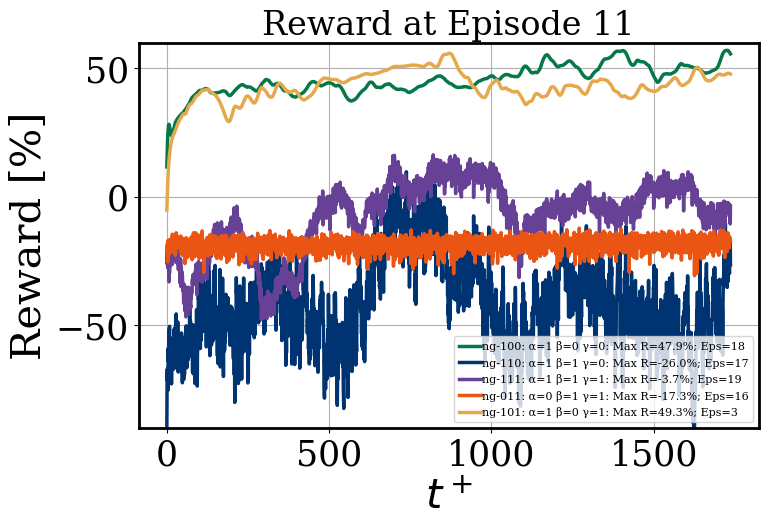

In [57]:
EPISODE_ID = 10; max_rew = -1000 
fig,axs = plt.subplots(1,1,figsize=(8,5))


for il, case in enumerate(case_list):
    label = case_name[il] 
    label = label + ": Max R={:.1f}%".format(case_dict[case]['reward_smooth_max'])
    label = label + "; Eps={}".format(case_dict[case]['reward_smooth_max_index'])
    # Get the time scale 
    u_tau = case_dict[case]['conf']['runner']['u_tau'] 
    Reb = 1./ np.abs(case_dict[case]['conf']['simulation']['viscosity'])
    t_star = Reb / u_tau**2
    #print(f"Reb = {Reb}, u_tau = {u_tau}, t_star = {t_star}")
    DT = np.abs(case_dict[case]['conf']['simulation']['dt'])
    ndrl = case_dict[case]['conf']['simulation']['ndrl']
    NSTEP = case_dict[case]['conf']['runner']['nb_interactions']
    TEND = NSTEP * DT * ndrl   
    t     = np.linspace(0,TEND,NSTEP)
    tplus = t/t_star
    try: 
        episode_data = case_dict[case]['reward'][EPISODE_ID][:]
        axs.plot(tplus[:NSTEP],episode_data,c=color_list[il],lw=2.5,label=label)

        if max_rew < np.max(episode_data): 
            max_rew = np.max(episode_data)
    except: 
        print(f'No data for {EPISODE_ID}')
        
axs.set_xlabel(r"$t^+$",)
axs.set_ylabel("Reward [%]",)
axs.set_title(f"Reward at Episode {EPISODE_ID+1}",)
axs.grid(True)
axs.set_ylim(-90,np.ceil(max_rew*1.05))
axs.legend(loc='lower right',prop={'size': 8})
plt.show()
if SAVE_IMG:
    plt.savefig(f"{fig_path}/reward_one_episode_{EPISODE_ID}_{datetime.datetime.now().strftime('%Y%m%d_%H%M%S')}.png",dpi=299)

